<a href="https://colab.research.google.com/github/akshithaa24/data-files/blob/main/YouTube_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Loading the specific YouTube dataset
df = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

# Step 2: Basic Commands
print(df.head())      # Technique: Head
print(df.info())      # Technique: Info
print(df.describe())  # Technique: Describe

   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0   
1           US  

In [4]:
# 1. Handling missing data: Filling nulls in 'category' and checking results
initial_nulls = df['category'].isnull().sum()
df['category'] = df['category'].fillna('Unknown')
print(f"Technique 1 - Missing Data: Fixed {initial_nulls} nulls in 'category'. Current nulls: {df['category'].isnull().sum()}")

# 2. Handling duplicate records: Removing and showing how many were removed
initial_count = len(df)
df = df.drop_duplicates()
print(f"\nTechnique 2 - Duplicates: Removed {initial_count - len(df)} duplicate rows. Total rows now: {len(df)}")

# 3. Detecting outliers: Using IQR to find extreme Total_Views
Q1 = df['Total_Views'].quantile(0.25)
Q3 = df['Total_Views'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_count = len(df[(df['Total_Views'] < lower_bound) | (df['Total_Views'] > upper_bound)])
print(f"\nTechnique 3 - Outliers: Detected {outliers_count} extreme view counts outside the range ({lower_bound:,.0f} to {upper_bound:,.0f})")

# 4. Handling inconsistent data: Trimming extra spaces from 'Title'
df['Title'] = df['Title'].astype(str).str.strip()
print("\nTechnique 4 - Inconsistent Data: Titles have been trimmed of leading/trailing spaces.")

# 5. Renaming columns: Printing the updated list of column names
# (Make sure you haven't renamed them already, or this might throw an error)
df.rename(columns={'video views': 'Total_Views', 'subscribers': 'Subscribers'}, inplace=True, errors='ignore')
print("\nTechnique 5 - Renaming: Column names updated. Current columns are:")
print(df.columns.tolist())

# Final verification: Show the first 3 rows of the cleaned data
print("\n--- Cleaned Data Preview ---")
df.head(3)

Technique 1 - Missing Data: Fixed 0 nulls in 'category'. Current nulls: 0

Technique 2 - Duplicates: Removed 0 duplicate rows. Total rows now: 995

Technique 3 - Outliers: Detected 52 extreme view counts outside the range (-9,611,689,254 to 27,454,536,518)

Technique 4 - Inconsistent Data: Titles have been trimmed of leading/trailing spaces.

Technique 5 - Renaming: Column names updated. Current columns are:
['rank', 'Youtuber', 'Subscribers', 'Total_Views', 'category', 'Title', 'uploads', 'Country', 'Abbreviation', 'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings', 'highest_monthly_earnings', 'lowest_yearly_earnings', 'highest_yearly_earnings', 'subscribers_for_last_30_days', 'created_year', 'created_month', 'created_date', 'Gross tertiary education enrollment (%)', 'Population', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude']

--- Cleaned Data Preview ---


,rank,Youtuber,Subscribers,Total_Views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891


In [5]:
# 6. Data type conversion: Ensuring 'created_year' is a number (float/int)
df['created_year'] = pd.to_numeric(df['created_year'], errors='coerce')
print(f"Technique 6 - Conversion: 'created_year' is now {df['created_year'].dtype}")

# 7. Scaling data: Using Standard Deviation scaling for Subscribers
df['Sub_Scaled'] = (df['Subscribers'] - df['Subscribers'].mean()) / df['Subscribers'].std()
print("\nTechnique 7 - Scaling: Subscribers have been scaled. Sample values:")
print(df['Sub_Scaled'].head())

# 8. Normalization technique: Scaling Total_Views between 0 and 1
df['Views_Norm'] = (df['Total_Views'] - df['Total_Views'].min()) / (df['Total_Views'].max() - df['Total_Views'].min())
print("\nTechnique 8 - Normalization: Views normalized between 0 and 1. Sample values:")
print(df['Views_Norm'].head())

# 9. Binning: Grouping channels into 3 categories: 'Bronze', 'Silver', 'Gold'
df['Account_Tier'] = pd.qcut(df['Subscribers'], 3, labels=["Bronze", "Silver", "Gold"])
print("\nTechnique 9 - Binning: Channels grouped into Tiers:")
print(df['Account_Tier'].value_counts())

# 10. Aggregation: Finding the Maximum earnings per Category
# Note: Ensure the column name matches 'highest_monthly_earnings' or similar in your CSV
df['highest_monthly_earnings'] = pd.to_numeric(df['highest_monthly_earnings'], errors='coerce')
earnings_agg = df.groupby('category')['highest_monthly_earnings'].max().sort_values(ascending=False).head(5)
print("\nTechnique 10 - Aggregation: Max Monthly Earnings by Category:")
print(earnings_agg)

Technique 6 - Conversion: 'created_year' is now float64

Technique 7 - Scaling: Subscribers have been scaled. Sample values:
0    12.667822
1     8.388492
2     8.160261
3     7.932030
4     7.760856
Name: Sub_Scaled, dtype: float64

Technique 8 - Normalization: Views normalized between 0 and 1. Sample values:
0    1.000000
1    0.000000
2    0.124425
3    0.719298
4    0.649123
Name: Views_Norm, dtype: float64

Technique 9 - Binning: Channels grouped into Tiers:
Account_Tier
Bronze    335
Gold      331
Silver    329
Name: count, dtype: int64

Technique 10 - Aggregation: Max Monthly Earnings by Category:
category
Unknown             13600000.0
Film & Animation     9200000.0
Music                9000000.0
Entertainment        8100000.0
Education            7900000.0
Name: highest_monthly_earnings, dtype: float64


Technique 11 - Mean Subscribers: 22,982,412
Technique 11 - Median Subscribers: 17,700,000


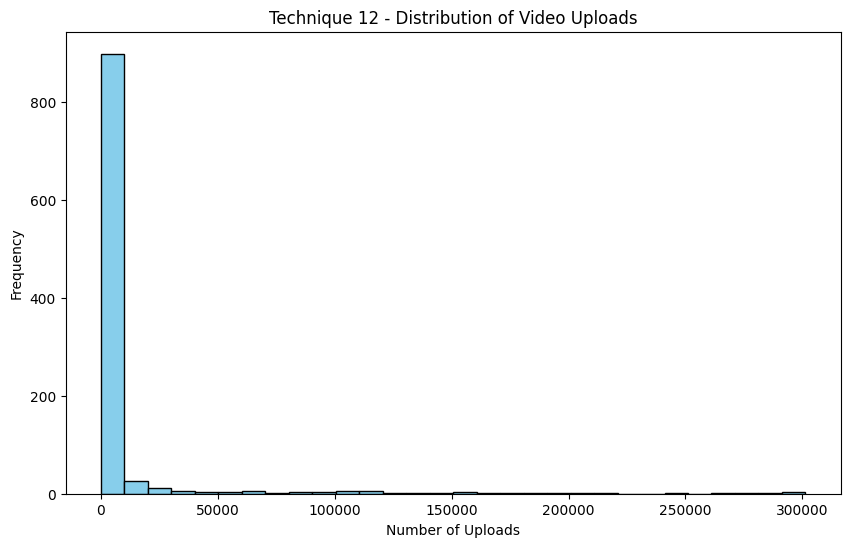

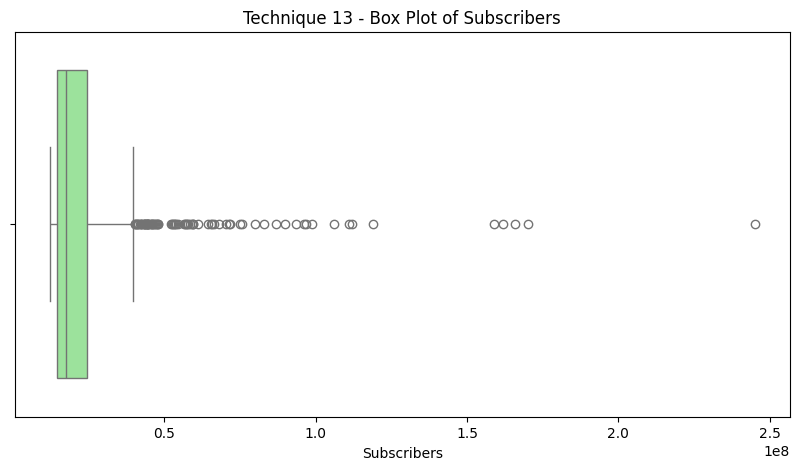

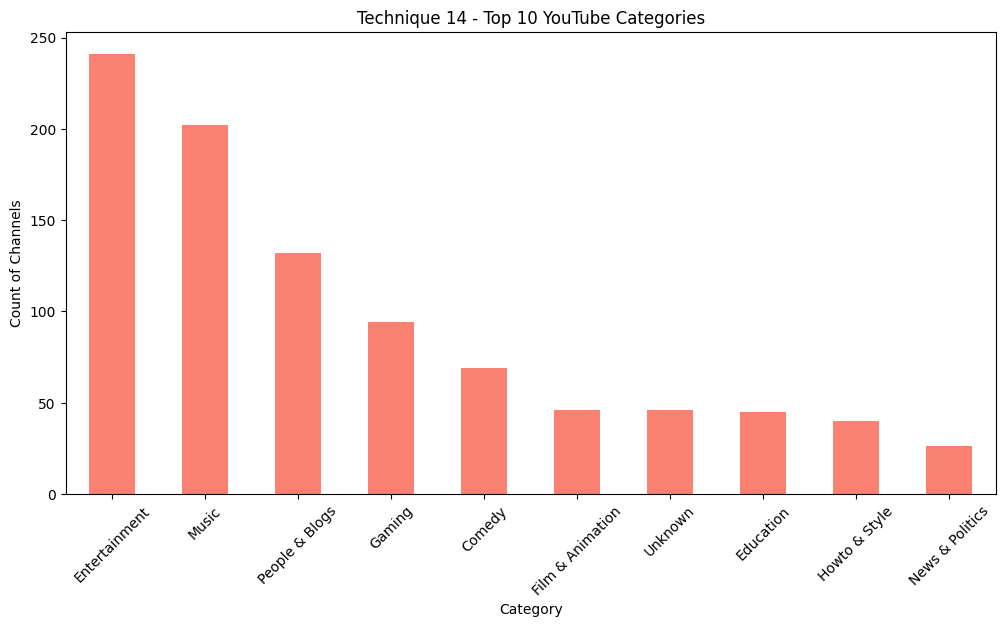

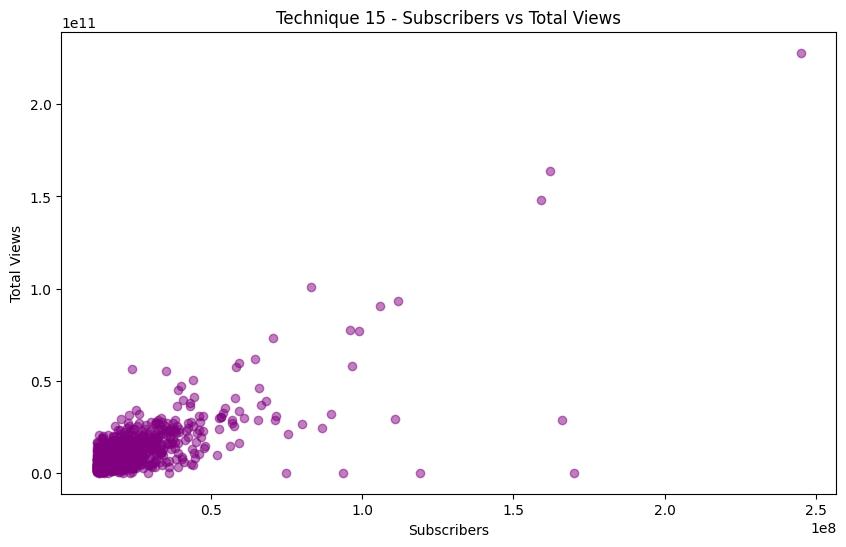

In [6]:
# 11. Central Tendency: Finding the Mean and Median of Subscribers
sub_mean = df['Subscribers'].mean()
sub_median = df['Subscribers'].median()
print(f"Technique 11 - Mean Subscribers: {sub_mean:,.0f}")
print(f"Technique 11 - Median Subscribers: {sub_median:,.0f}")

# 12. Histogram: Showing the distribution of 'uploads'
plt.figure(figsize=(10, 6))
plt.hist(df['uploads'], bins=30, color='skyblue', edgecolor='black')
plt.title('Technique 12 - Distribution of Video Uploads')
plt.xlabel('Number of Uploads')
plt.ylabel('Frequency')
plt.show()

# 13. Box Plot: Visualizing 'Subscribers' to see the spread and outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Subscribers'], color='lightgreen')
plt.title('Technique 13 - Box Plot of Subscribers')
plt.show()

# 14. Bar Chart: Top 10 Categories by number of channels
plt.figure(figsize=(12, 6))
df['category'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Technique 14 - Top 10 YouTube Categories')
plt.xlabel('Category')
plt.ylabel('Count of Channels')
plt.xticks(rotation=45)
plt.show()

# 15. Scatter Plot: Relationship between Subscribers and Total Views
plt.figure(figsize=(10, 6))
plt.scatter(df['Subscribers'], df['Total_Views'], alpha=0.5, color='purple')
plt.title('Technique 15 - Subscribers vs Total Views')
plt.xlabel('Subscribers')
plt.ylabel('Total Views')
plt.show()

In [8]:
# 16. One Hot Encoding: Creating dummy variables for 'channel_type'
# This creates separate columns for types like 'Entertainment', 'Music', etc.
df_encoded = pd.get_dummies(df, columns=['channel_type'], prefix='type')
print("Technique 16 - One Hot Encoding (First 5 rows of new columns):")
print(df_encoded.filter(like='type_').head())

# 17. Label Encoding: Giving each 'Country' a unique number
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['country_encoded'] = le.fit_transform(df['Country'].astype(str))
print("\nTechnique 17 - Label Encoding:")
print(df[['Country', 'country_encoded']].head())

# 18. Feature Extraction: Extracting 'Channel Age' from the year
# Subtracting creation year from the current year (2026)
df['Channel_Age'] = 2026 - df['created_year']
print("\nTechnique 18 - Feature Extraction (Channel Age):")
print(df[['Youtuber', 'created_year', 'Channel_Age']].head())

# 19. Text Processing - Lower Casing: Making Youtuber names lowercase
df['youtuber_lower'] = df['Youtuber'].str.lower()
print("\nTechnique 19 - Lower Casing (First 5 names):")
print(df['youtuber_lower'].head())

# 20. Text Processing - Tokenization: Splitting 'category' into words
df['category_tokens'] = df['category'].str.split()
print("\nTechnique 20 - Tokenization (Splitting Categories):")
print(df['category_tokens'].head())

Technique 16 - One Hot Encoding (First 5 rows of new columns):
   channel_type_rank  type_Animals  type_Autos  type_Comedy  type_Education  \
0                1.0         False       False        False           False   
1             7423.0         False       False        False           False   
2                1.0         False       False        False           False   
3                1.0         False       False        False            True   
4                2.0         False       False        False           False   

   type_Entertainment  type_Film  type_Games  type_Howto  type_Music  \
0               False      False       False       False        True   
1               False      False        True       False       False   
2                True      False       False       False       False   
3               False      False       False       False       False   
4                True      False       False       False       False   

   type_News  type_Nonprofit 